# Feature Split Analysis

This file analyzes the MetadataLoaders Split funciton. It has three parts

1. **HUNT EDA:** Analyze the distributions of the external features.
2. **Normalization analyzis:** Make sure that the MetdataLoader actually normalizes the dataset correctly, keeping the same distributions
3. **Feature-based split:** Make sure the `MetaDataLoader.split()` splits the dataset well, keeping good distributions.

## Setup

In [1]:
import sys
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from utils.metadata_loader import MetaDataLoader

In [2]:
SEED        = 67
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
# Test split is also 0.15

# These are not neccesary for the split, but makes analysis easier
CONTINUOUS  = ['waist_circumference_cm', 'hip_circumference_cm', 'diastolic_bp_mmhg', 'systolic_bp_mmhg', 'blood_glucose_mmol_l', 'bmi_kg_m2', 'pack_years', 'had_score']
CATEGORICAL = ['education_level', 'diabetes', 'self_rated_health', 'smoking_status']
BINARY      = ['employment_status']
ALL_VARS    = CONTINUOUS + CATEGORICAL + BINARY

# These are not neccesary for the split, but makes analysis easier
SPLIT_NAMES  = ['Train', 'Validation', 'Test']
SPLIT_COLORS = ['steelblue', 'darkorange', 'seagreen']

---
## Part 1 — HUNT External Data EDA

In [3]:
raw  = pd.read_csv('data/metadata/mock_metadata.csv')
norm = pd.read_csv('data/metadata/mock_metadata_normalized.csv')

print(f"Raw  : {raw.shape[0]} subjects × {raw.shape[1]-1} features")
print(f"Norm : {norm.shape[0]} subjects × {norm.shape[1]-1} columns "
      f"(categoricals one-hot encoded)")
display(raw.head(5))

Raw  : 703 subjects × 13 features
Norm : 703 subjects × 25 columns (categoricals one-hot encoded)


,MR_HUNT_ID,education_level,employment_status,waist_circumference_cm,hip_circumference_cm,diastolic_bp_mmhg,systolic_bp_mmhg,blood_glucose_mmol_l,bmi_kg_m2,diabetes,self_rated_health,smoking_status,pack_years,had_score
0,9410000000039,Long higher ed,0,94.5,95.1,92.2,138.9,4.77,24.6,Yes,Excellent,Former,21.2,12.1
1,9410000000046,Upper secondary,1,95.9,83.8,87.4,129.3,5.31,22.8,No,Very good,Never,0.0,4.9
2,9410000000053,Upper secondary,0,87.0,119.5,62.5,114.6,6.81,32.1,No,Good,Current,34.2,1.9
3,9410000000077,Short higher ed,0,88.8,110.3,75.0,108.7,6.39,28.9,No,Very good,Former,7.7,10.1
4,9410000000091,Short higher ed,0,103.5,109.7,89.0,118.8,6.32,29.5,No,Very good,Never,0.0,5.1


### Variable overview

In [4]:
rows = []
for col in ALL_VARS:
    kind = ('Continuous' if col in CONTINUOUS
            else 'Binary'      if col in BINARY
            else 'Categorical')
    rows.append({
        'Variable': col,
        'Type':     kind,
        'N unique': raw[col].nunique(),
        'Missing':  int(raw[col].isna().sum()),
        'Values / range': (
            f"{raw[col].min():.2f} – {raw[col].max():.2f}" if col in CONTINUOUS
            else str(sorted(raw[col].unique().tolist()))
        ),
    })
display(pd.DataFrame(rows).set_index('Variable'))

,Type,N unique,Missing,Values / range
Variable,,,,
waist_circumference_cm,Continuous,384,0,51.20 – 127.60
hip_circumference_cm,Continuous,326,0,74.50 – 132.90
diastolic_bp_mmhg,Continuous,321,0,51.70 – 112.50
systolic_bp_mmhg,Continuous,440,0,71.40 – 186.90
blood_glucose_mmol_l,Continuous,333,0,3.43 – 10.31
bmi_kg_m2,Continuous,207,0,15.00 – 43.00
pack_years,Continuous,271,0,0.00 – 95.60
had_score,Continuous,191,0,0.00 – 26.90
education_level,Categorical,5,0,"['Long higher ed', 'Lower secondary', 'None/Pr..."


### Continuous variables 

In [5]:
stats = raw[CONTINUOUS].agg(['min','max','mean','median','std','var']).round(3)
display(stats.T.rename(columns=str.title))

,Min,Max,Mean,Median,Std,Var
waist_circumference_cm,51.20,127.60,91.303,91.60,13.104,171.713
hip_circumference_cm,74.50,132.90,102.272,102.20,9.927,98.545
diastolic_bp_mmhg,51.70,112.50,78.005,77.60,9.737,94.817
systolic_bp_mmhg,71.40,186.90,127.399,127.50,18.370,337.461
blood_glucose_mmol_l,3.43,10.31,5.857,5.77,1.034,1.069
bmi_kg_m2,15.00,43.00,27.316,27.20,5.181,26.840
pack_years,0.00,95.60,11.965,5.30,15.927,253.661
had_score,0.00,26.90,8.115,8.00,5.263,27.699


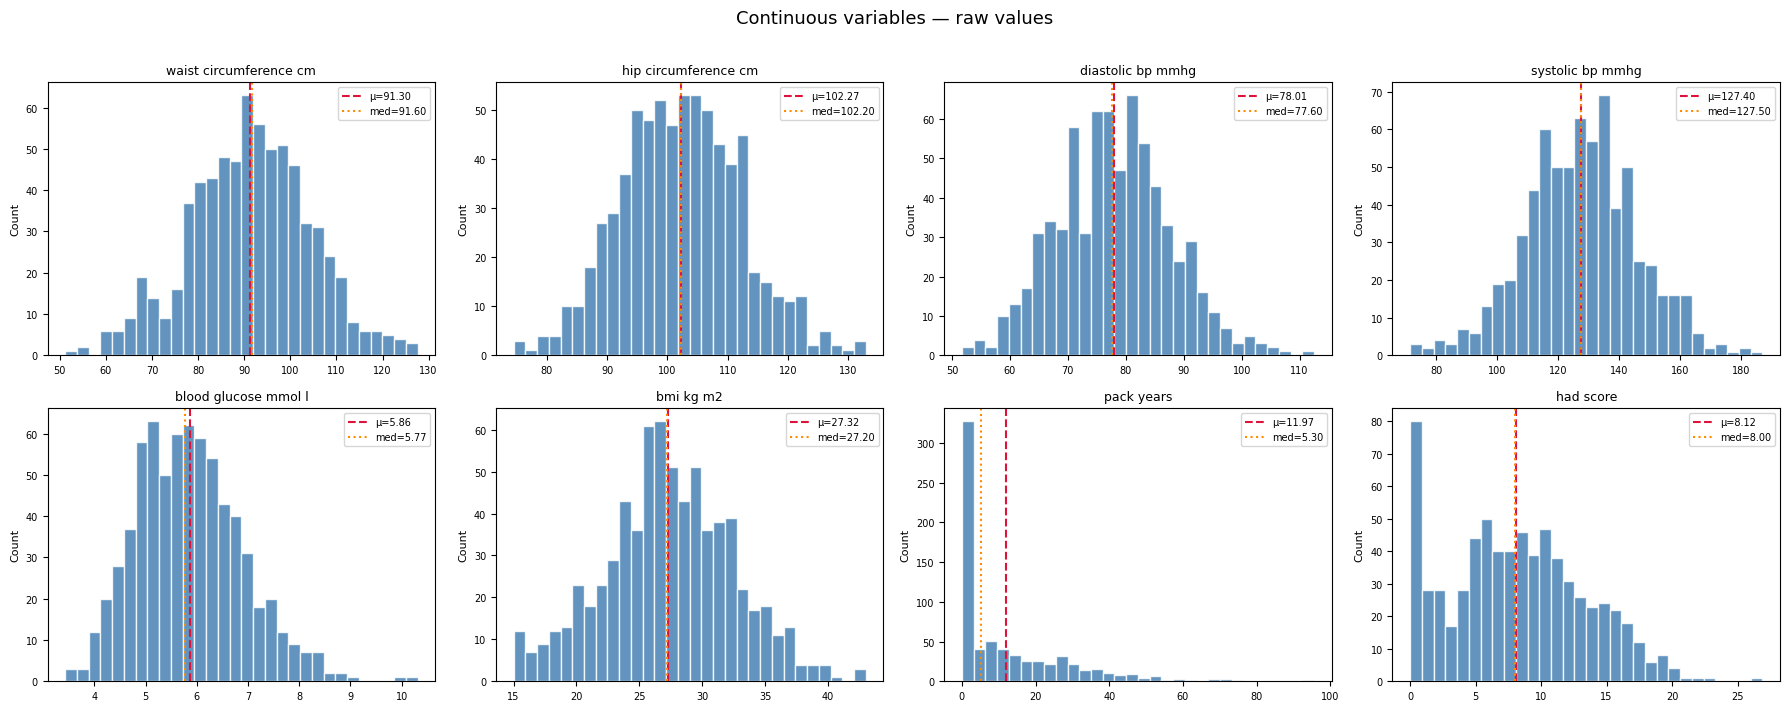

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, CONTINUOUS):
    data = raw[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='crimson',    linestyle='--', lw=1.5,
               label=f'μ={data.mean():.2f}')
    ax.axvline(data.median(), color='darkorange', linestyle=':',  lw=1.5,
               label=f'med={data.median():.2f}')
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
plt.suptitle('Continuous variables — raw values', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Categorical & binary variables — distributions

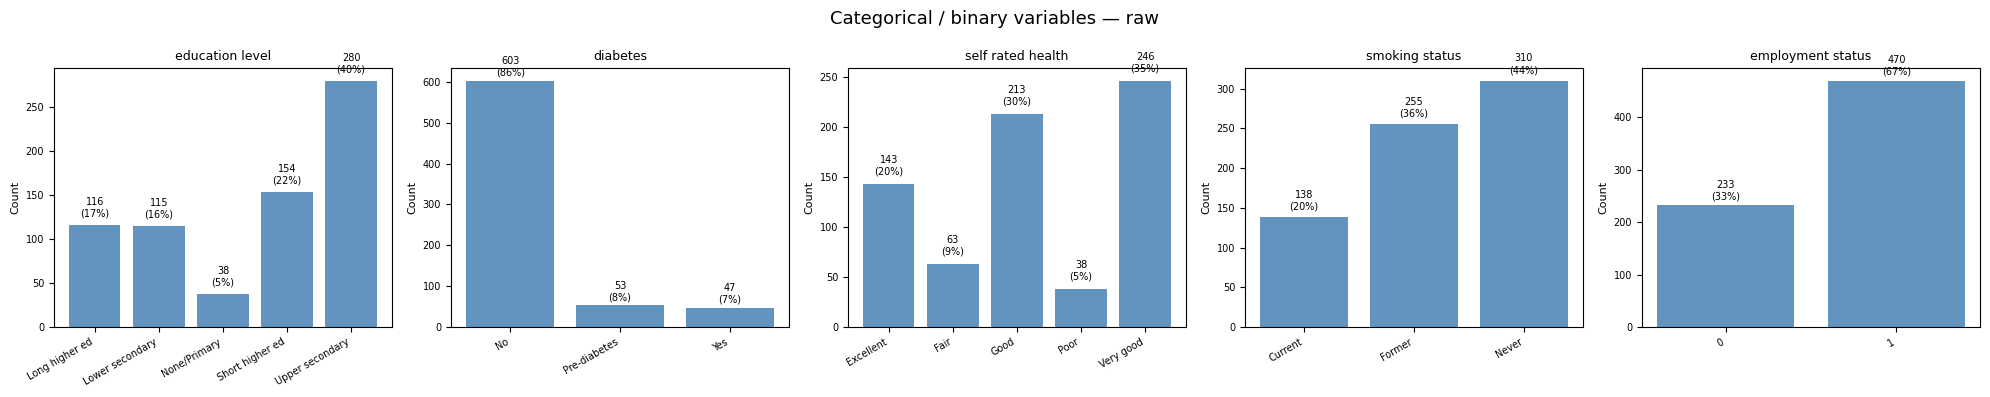

In [7]:
ALL_CAT = CATEGORICAL + BINARY
fig, axes = plt.subplots(1, len(ALL_CAT), figsize=(20, 4))
for ax, col in zip(axes, ALL_CAT):
    vc = raw[col].value_counts().sort_index()
    bars = ax.bar(range(len(vc)), vc.values, color='steelblue', alpha=0.85)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([str(v) for v in vc.index], rotation=30, ha='right', fontsize=8)
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.set_ylabel('Count', fontsize=8)
    total = vc.sum()
    for bar, count in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{count}\n({count/total*100:.0f}%)',
                ha='center', va='bottom', fontsize=7)
    ax.tick_params(labelsize=7)
plt.suptitle('Categorical / binary variables — raw', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
for col in CATEGORICAL + BINARY:
    vc = raw[col].value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    tbl = pd.concat([vc, pct], axis=1, keys=['Count','%'])
    tbl.index.name = col
    display(tbl)

,Count,%
education_level,,
Long higher ed,116,16.5
Lower secondary,115,16.4
None/Primary,38,5.4
Short higher ed,154,21.9
Upper secondary,280,39.8


,Count,%
diabetes,,
No,603,85.8
Pre-diabetes,53,7.5
Yes,47,6.7


,Count,%
self_rated_health,,
Excellent,143,20.3
Fair,63,9.0
Good,213,30.3
Poor,38,5.4
Very good,246,35.0


,Count,%
smoking_status,,
Current,138,19.6
Former,255,36.3
Never,310,44.1


,Count,%
employment_status,,
0,233,33.1
1,470,66.9


---
## Part 2 — Normalisation

The normaliser (`metadata_normalizer.py`) splits data differently, automatically detecting which category a variable belongs to:
- **Continuous** → min-max scaled to **[0, 1]** (shape unchanged, range compressed).
- **Binary** (2 unique values) → mapped to **0 / 1** (already encoded, no change).
- **Categorical** (≥ 3 string values) → **one-hot encoded** into separate binary columns.

This section verifies each transformation.

### Column mapping

In [9]:
norm_feat_cols = [c for c in norm.columns if c != 'MR_HUNT_ID']

# Build one-hot groups dynamically from norm column names
ohe_groups = {}
for cat in CATEGORICAL:
    ohe_groups[cat] = [c for c in norm_feat_cols if c.startswith(cat + '_')]

rows = []
for col in ALL_VARS:
    if col in CONTINUOUS:
        rows.append({'Raw column': col, 'Transformation': 'min-max → [0, 1]',
                     'Normalised column(s)': col})
    elif col in BINARY:
        rows.append({'Raw column': col, 'Transformation': 'binary (0 / 1, unchanged)',
                     'Normalised column(s)': col})
    else:
        ohe = ohe_groups[col]
        rows.append({'Raw column': col,
                     'Transformation': f'one-hot ({len(ohe)} levels)',
                     'Normalised column(s)': ', '.join(
                         c.replace(col + '_','') for c in ohe)})

display(pd.DataFrame(rows).set_index('Raw column'))

,Transformation,Normalised column(s)
Raw column,,
waist_circumference_cm,"min-max → [0, 1]",waist_circumference_cm
hip_circumference_cm,"min-max → [0, 1]",hip_circumference_cm
diastolic_bp_mmhg,"min-max → [0, 1]",diastolic_bp_mmhg
systolic_bp_mmhg,"min-max → [0, 1]",systolic_bp_mmhg
blood_glucose_mmol_l,"min-max → [0, 1]",blood_glucose_mmol_l
bmi_kg_m2,"min-max → [0, 1]",bmi_kg_m2
pack_years,"min-max → [0, 1]",pack_years
had_score,"min-max → [0, 1]",had_score
education_level,one-hot (5 levels),"long_higher_ed, lower_secondary, none_primary,..."


### Continuous variables — raw vs normalised

Shape is **identical** — only the axis scale changes (original units → [0, 1]).

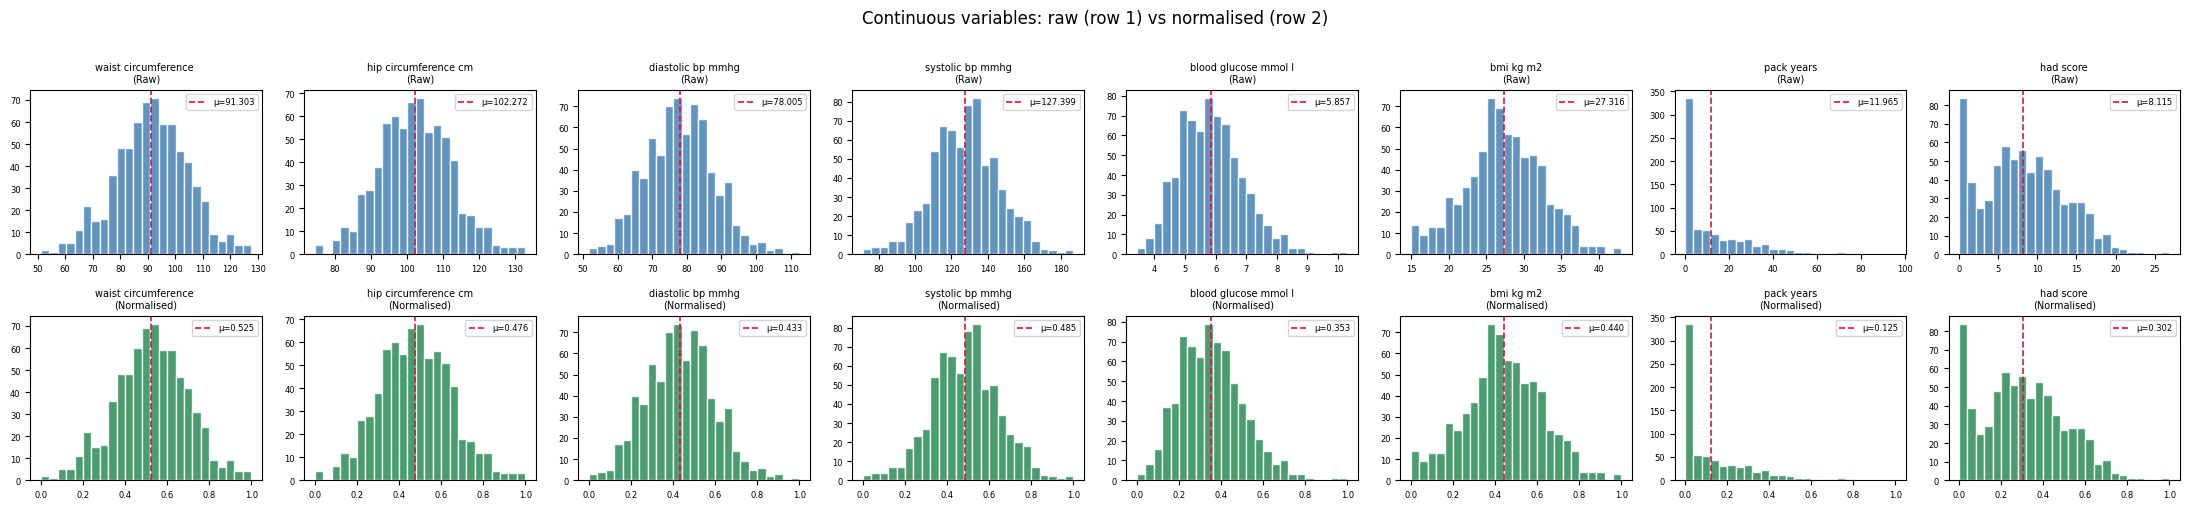

In [10]:
fig, axes = plt.subplots(2, 8, figsize=(22, 5))
raw_axes  = axes[0]   # 8 axes, one per variable
norm_axes = axes[1]

for col, ax_r, ax_n in zip(CONTINUOUS, raw_axes, norm_axes):
    r_data = raw[col].dropna()
    n_data = norm[col].dropna()

    for ax, data, color, label in [
        (ax_r, r_data, 'steelblue', 'Raw'),
        (ax_n, n_data, 'seagreen',  'Normalised'),
    ]:
        ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(data.mean(), color='crimson', linestyle='--', lw=1.2,
                   label=f'μ={data.mean():.3f}')
        ax.set_title(col.replace('_',' ')[:20] + f'\n({label})', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)

plt.suptitle('Continuous variables: raw (row 1) vs normalised (row 2)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Normalised continuous statistics

In [ ]:
norm_stats = norm[CONTINUOUS].agg(['min','max','mean','median','std','var']).round(4)
print("All min ≈ 0, max ≈ 1 — distribution shape preserved.")
display(norm_stats.T.rename(columns=str.title))

All min ≈ 0, max ≈ 1 — distribution shape preserved.


,Min,Max,Mean,Median,Std,Var
waist_circumference_cm,0.0,1.0,0.5249,0.5288,0.1715,0.0294
hip_circumference_cm,0.0,1.0,0.4755,0.4743,0.1700,0.0289
diastolic_bp_mmhg,0.0,1.0,0.4327,0.4260,0.1602,0.0256
systolic_bp_mmhg,0.0,1.0,0.4848,0.4857,0.1590,0.0253
blood_glucose_mmol_l,0.0,1.0,0.3528,0.3401,0.1503,0.0226
bmi_kg_m2,0.0,1.0,0.4398,0.4357,0.1850,0.0342
pack_years,0.0,1.0,0.1252,0.0554,0.1666,0.0278
had_score,0.0,1.0,0.3017,0.2974,0.1956,0.0383


### One-hot encoded categoricals

Each categorical variable is split into binary indicator columns.
The **mean** of each column equals the **fraction** of subjects in that category — identical to the raw percentage, just encoded as a number in [0, 1].

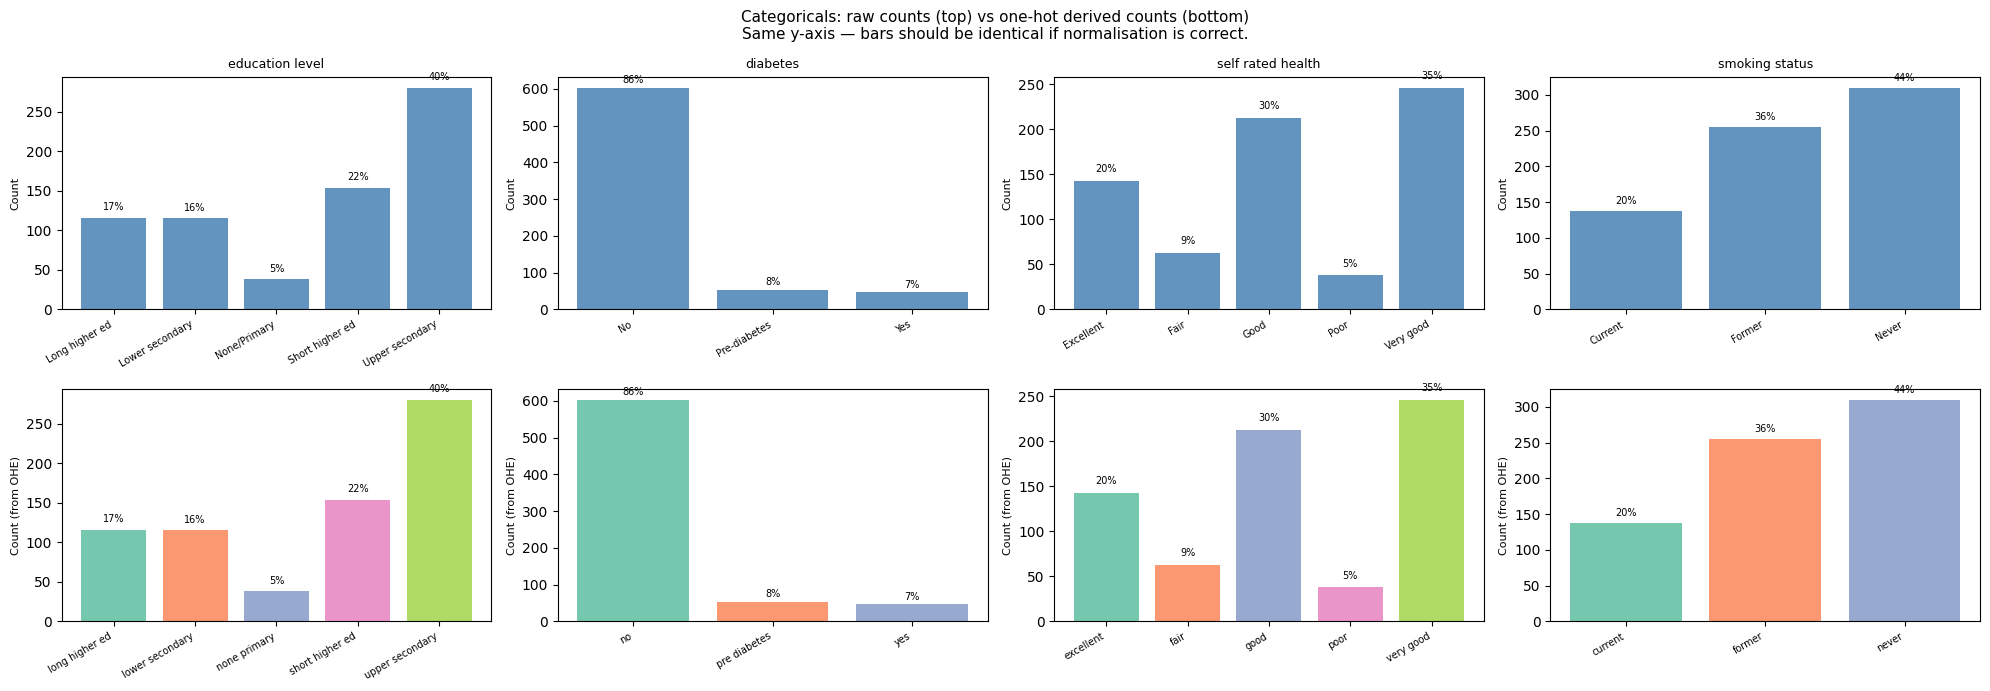

In [12]:
n_cats = len(CATEGORICAL)
n_subj = len(norm)
fig, axes = plt.subplots(2, n_cats, figsize=(20, 7))

for col_i, cat in enumerate(CATEGORICAL):
    ohe_cols = ohe_groups[cat]
    labels   = [c.replace(cat + '_','').replace('_',' ') for c in ohe_cols]
    raw_vc   = raw[cat].value_counts().sort_index()
    means    = norm[ohe_cols].mean().values
    counts   = means * n_subj  # fraction -> count, matches raw y-axis

    # Top row: raw counts
    ax_top = axes[0, col_i]
    ax_top.bar(range(len(raw_vc)), raw_vc.values, color='steelblue', alpha=0.85)
    ax_top.set_xticks(range(len(raw_vc)))
    ax_top.set_xticklabels([str(v).replace('_',' ') for v in raw_vc.index],
                            rotation=30, ha='right', fontsize=7)
    ax_top.set_title(cat.replace('_',' '), fontsize=9)
    ax_top.set_ylabel('Count', fontsize=8)
    for i, v in enumerate(raw_vc.values):
        ax_top.text(i, v + n_subj*0.01, f'{v/n_subj*100:.0f}%',
                    ha='center', va='bottom', fontsize=7)

    # Bottom row: same count scale derived from OHE means
    ax_bot = axes[1, col_i]
    bars = ax_bot.bar(range(len(labels)), counts,
                      color=plt.cm.Set2.colors[:len(labels)], alpha=0.9)
    ax_bot.set_xticks(range(len(labels)))
    ax_bot.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
    ax_bot.set_ylabel('Count (from OHE)', fontsize=8)
    ax_bot.set_ylim(0, ax_top.get_ylim()[1])  # match raw y-axis
    for bar, c_val, m in zip(bars, counts, means):
        ax_bot.text(bar.get_x() + bar.get_width()/2, c_val + n_subj*0.01,
                    f'{m*100:.0f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Categoricals: raw counts (top) vs one-hot derived counts (bottom)\n'
             'Same y-axis — bars should be identical if normalisation is correct.',
             fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
print("One-hot column statistics (mean = fraction, std reflects imbalance)\n")
for cat in CATEGORICAL:
    ohe_cols = ohe_groups[cat]
    tbl = norm[ohe_cols].agg(['mean','std','min','max']).round(4)
    tbl.columns = [c.replace(cat + '_','') for c in tbl.columns]
    tbl.index.name = cat
    display(tbl)
    print()

One-hot column statistics (mean = fraction, std reflects imbalance)



,long_higher_ed,lower_secondary,none_primary,short_higher_ed,upper_secondary
education_level,,,,,
mean,0.1650,0.1636,0.0541,0.2191,0.3983
std,0.3715,0.3702,0.2263,0.4139,0.4899
min,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000


,no,pre_diabetes,yes
diabetes,,,
mean,0.8578,0.0754,0.0669
std,0.3496,0.2642,0.2500
min,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000


,excellent,fair,good,poor,very_good
self_rated_health,,,,,
mean,0.2034,0.0896,0.3030,0.0541,0.3499
std,0.4028,0.2858,0.4599,0.2263,0.4773
min,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000


,current,former,never
smoking_status,,,
mean,0.1963,0.3627,0.4410
std,0.3975,0.4811,0.4969
min,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000


---
## Part 3 — Feature-Wise Split Analysis of normalised values

`MetaDataLoader.split()` stratifies over sex, age, and all 13 external features.
All analysis below uses **normalised values** — the actual numbers the model sees.

In [14]:
meta_loader = MetaDataLoader(external_features=True)
train_ids, val_ids, test_ids = meta_loader.split(
    train_split=TRAIN_SPLIT, val_split=VAL_SPLIT, seed=SEED
)

id_to_split = {}
id_to_split.update({i: 'Train'      for i in train_ids})
id_to_split.update({i: 'Validation' for i in val_ids})
id_to_split.update({i: 'Test'       for i in test_ids})

# Attach split labels to normalised dataframe
norm['hunt_id'] = norm['MR_HUNT_ID'].astype(str).str[-5:]
norm_s = norm.copy()
norm_s['split'] = norm_s['hunt_id'].map(id_to_split)
norm_s = norm_s.dropna(subset=['split'])
norm_s['split'] = pd.Categorical(norm_s['split'],
                                  categories=SPLIT_NAMES, ordered=True)

totals = norm_s['split'].value_counts().sort_index()
print(f"Seed: {SEED}  |  Total: {len(norm_s)} subjects")
for name, n in totals.items():
    print(f"  {name:<12} {n:>4}  ({n/len(norm_s)*100:.1f}%)")

Seed: 67  |  Total: 703 subjects
  Train         481  (68.4%)
  Validation    108  (15.4%)
  Test          114  (16.2%)


### Continuous variables — per-split distributions (normalised, [0, 1])

Box plots and overlapping density histograms. Values near 0 / 1 indicate the extreme of that feature across the full cohort.

/tmp/ipykernel_1245471/2370715208.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_split, labels=['Train','Val','Test'],
/tmp/ipykernel_1245471/2370715208.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_split, labels=['Train','Val','Test'],
/tmp/ipykernel_1245471/2370715208.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_split, labels=['Train','Val','Test'],
/tmp/ipykernel_1245471/2370715208.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old na

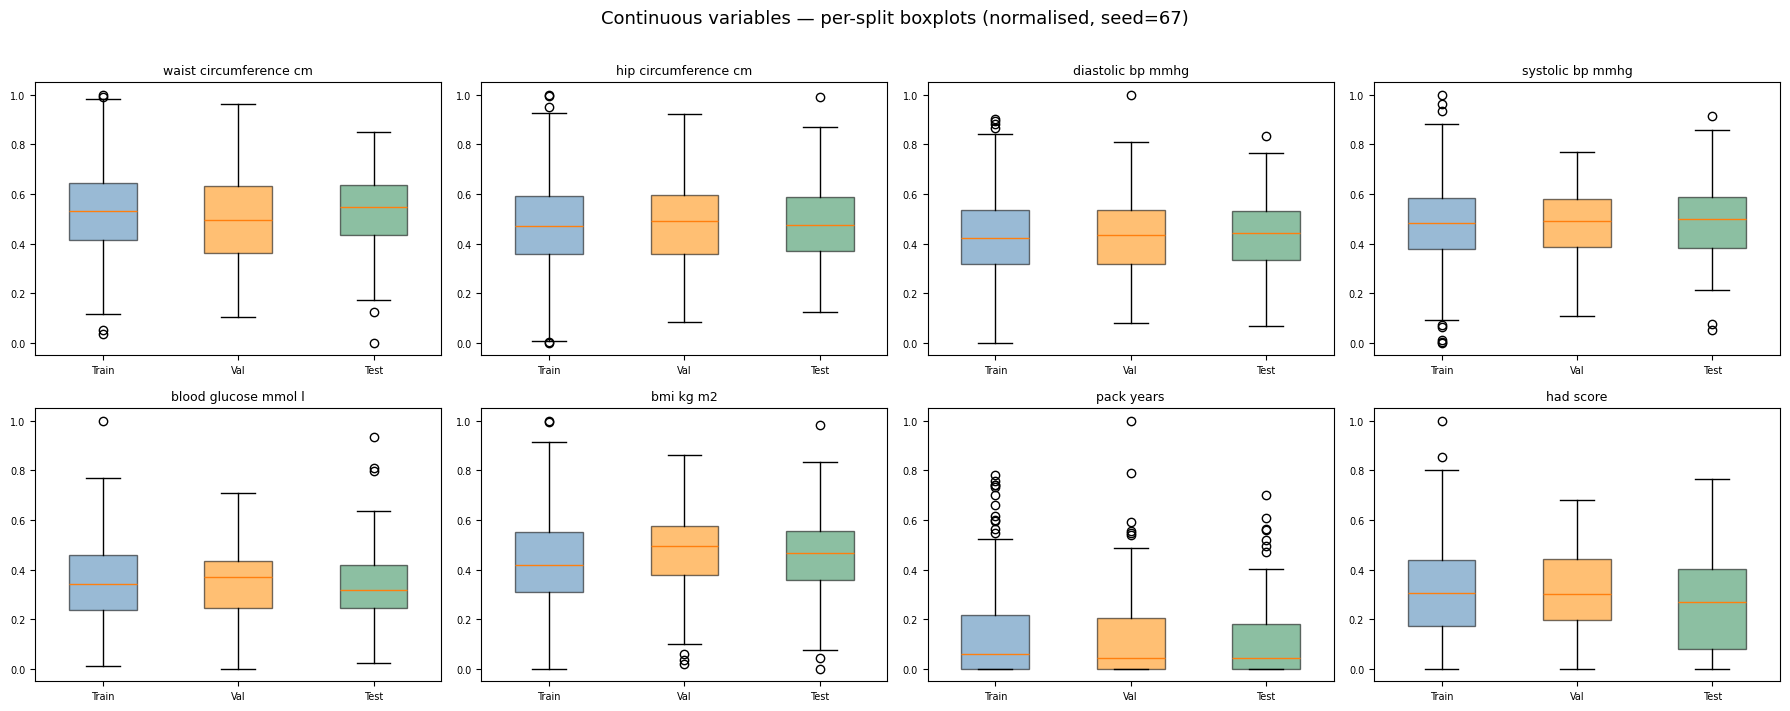

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, CONTINUOUS):
    data_by_split = [norm_s[norm_s['split']==s][col].dropna() for s in SPLIT_NAMES]
    bp = ax.boxplot(data_by_split, labels=['Train','Val','Test'],
                    patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], SPLIT_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.55)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.tick_params(labelsize=7)
plt.suptitle(f'Continuous variables — per-split boxplots (normalised, seed={SEED})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

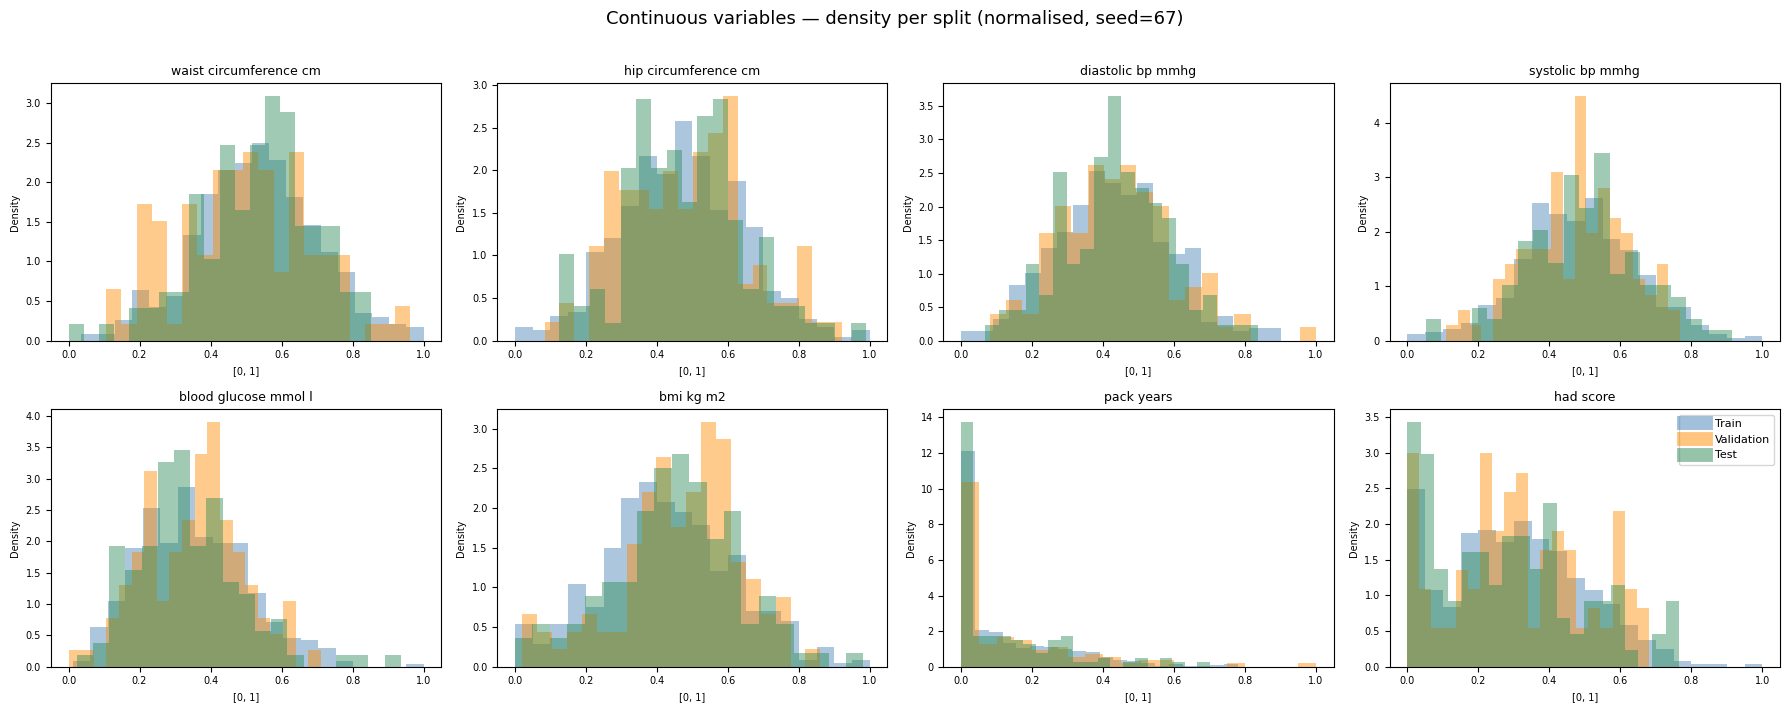

In [16]:
legend_handles = [Line2D([0],[0], color=c, lw=10, alpha=0.5, label=s)
                  for s, c in zip(SPLIT_NAMES, SPLIT_COLORS)]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, CONTINUOUS):
    for split_name, color in zip(SPLIT_NAMES, SPLIT_COLORS):
        sub = norm_s[norm_s['split']==split_name][col].dropna()
        ax.hist(sub, bins=20, density=True, alpha=0.45, color=color)
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.set_xlabel('[0, 1]', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=7)
axes.flat[-1].legend(handles=legend_handles, loc='upper right', fontsize=8)
plt.suptitle(f'Continuous variables — density per split (normalised, seed={SEED})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
stat_rows = []
for col in CONTINUOUS:
    for split_name in SPLIT_NAMES:
        s = norm_s[norm_s['split']==split_name][col].dropna()
        stat_rows.append({'Variable': col, 'Split': split_name,
                          'Min': s.min(), 'Max': s.max(),
                          'Mean': s.mean(), 'Median': s.median(),
                          'Std': s.std(), 'Var': s.var()})
stats_df = pd.DataFrame(stat_rows).set_index(['Variable','Split']).round(4)
display(stats_df)

Min     Max    Mean  Median     Std  \
Variable               Split                                                
waist_circumference_cm Train       0.0340  1.0000  0.5307  0.5301  0.1702   
                       Validation  0.1060  0.9634  0.4938  0.4935  0.1876   
                       Test        0.0000  0.8508  0.5299  0.5484  0.1589   
hip_circumference_cm   Train       0.0000  1.0000  0.4716  0.4726  0.1709   
                       Validation  0.0839  0.9212  0.4849  0.4906  0.1723   
                       Test        0.1250  0.9897  0.4832  0.4769  0.1649   
diastolic_bp_mmhg      Train       0.0000  0.9013  0.4311  0.4227  0.1630   
                       Validation  0.0806  1.0000  0.4365  0.4334  0.1620   
                       Test        0.0674  0.8355  0.4354  0.4433  0.1472   
systolic_bp_mmhg       Train       0.0000  1.0000  0.4829  0.4823  0.1634   
                       Validation  0.1100  0.7680  0.4791  0.4926  0.1402   
                       Test        0.0519  0.9160  0.4986  0.4974  0.1579   
blood_glucose_mmol_l   Train       0.0116  1.0000  0.3551  0.3401  0.1536   
                       Validation  0.0000  0.7108  0.3561  0.3699  0.1345   
                       Test        0.0233  0.9360  0.3396  0.3183  0.1510   
bmi_kg_m2              Train       0.0000  1.0000  0.4300  0.4179  0.1899   
                       Validation  0.0214  0.8607  0.4703  0.4964  0.1662   
                       Test        0.0000  0.9821  0.4526  0.4679  0.1786   
pack_years             Train       0.0000  0.7803  0.1253  0.0586  0.1636   
                       Validation  0.0000  1.0000  0.1305  0.0439  0.1870   
                       Test        0.0000  0.7008  0.1195  0.0455  0.1597   
had_score              Train       0.0000  1.0000  0.3046  0.3048  0.1945   
                       Validation  0.0000  0.6803  0.3143  0.3011  0.1888   
                       Test        0.0000  0.7658  0.2775  0.2677  0.2064   

                                      Var  
Variable               Split               
waist_circumference_cm Train       0.0290  
                       Validation  0.0352  
                       Test        0.0252  
hip_circumference_cm   Train       0.0292  
                       Validation  0.0297  
                       Test        0.0272  
diastolic_bp_mmhg      Train       0.0266  
                       Validation  0.0262  
                       Test        0.0217  
systolic_bp_mmhg       Train       0.0267  
                       Validation  0.0197  
                       Test        0.0249  
blood_glucose_mmol_l   Train       0.0236  
                       Validation  0.0181  
                       Test        0.0228  
bmi_kg_m2              Train       0.0361  
                       Validation  0.0276  
                       Test        0.0319  
pack_years             Train       0.0268  
                       Validation  0.0350  
                       Test        0.0255  
had_score              Train       0.0378  
                       Validation  0.0357  
                       Test        0.0426

### One-hot encoded categoricals — composition per split

**% within split** (top): of subjects in each split, what fraction carries each category?
All three bars should look similar — this is the stratification quality check.

**% across splits** (bottom): of all subjects with a given category, what fraction
landed in each split? Dashed lines show the target 70 / 15 / 15 ratio.

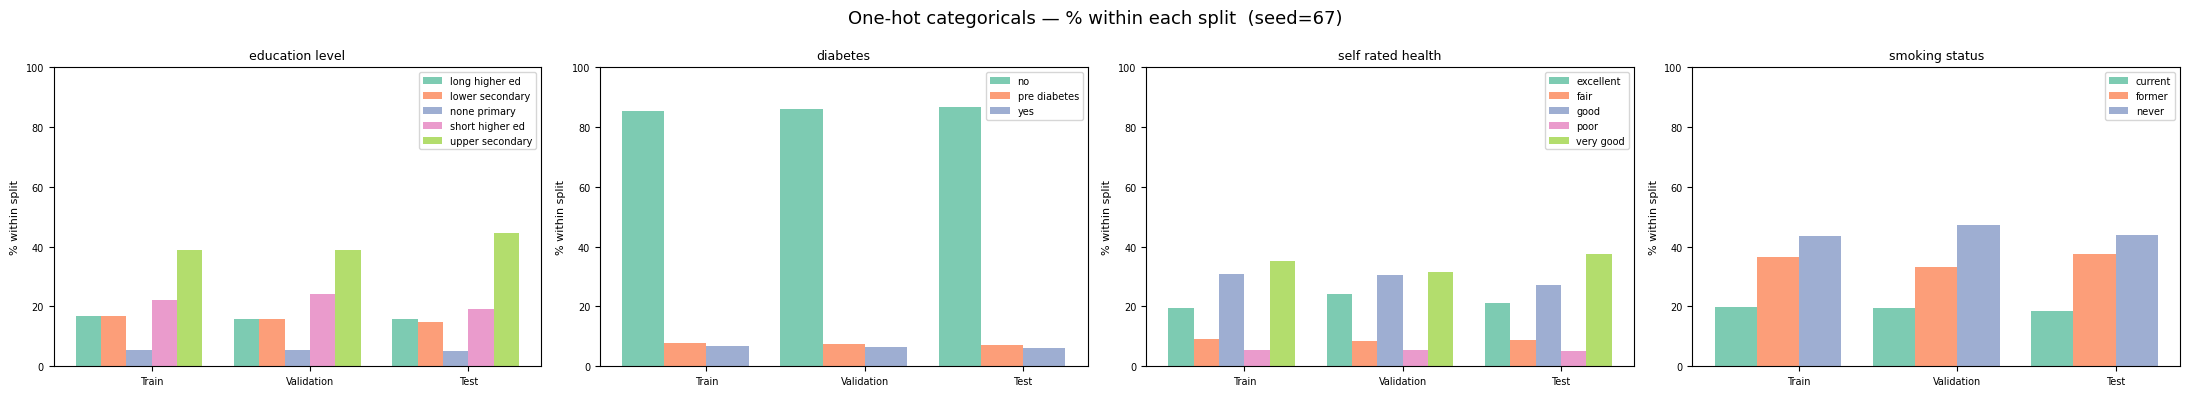

In [18]:
fig, axes = plt.subplots(1, len(CATEGORICAL), figsize=(22, 4))
for ax, cat in zip(axes, CATEGORICAL):
    ohe_cols = ohe_groups[cat]
    labels   = [c.replace(cat + '_','').replace('_',' ') for c in ohe_cols]

    x     = np.arange(len(SPLIT_NAMES))
    width = 0.8 / len(ohe_cols)
    colors = plt.cm.Set2.colors

    for j, (col, label) in enumerate(zip(ohe_cols, labels)):
        pcts = [norm_s[norm_s['split']==s][col].mean()*100 for s in SPLIT_NAMES]
        ax.bar(x + j*width - width*len(ohe_cols)/2, pcts, width,
               label=label, color=colors[j], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(SPLIT_NAMES, fontsize=8)
    ax.set_title(cat.replace('_',' '), fontsize=9)
    ax.set_ylabel('% within split', fontsize=8)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)

plt.suptitle(f'One-hot categoricals — % within each split  (seed={SEED})', fontsize=13)
plt.tight_layout()
plt.show()

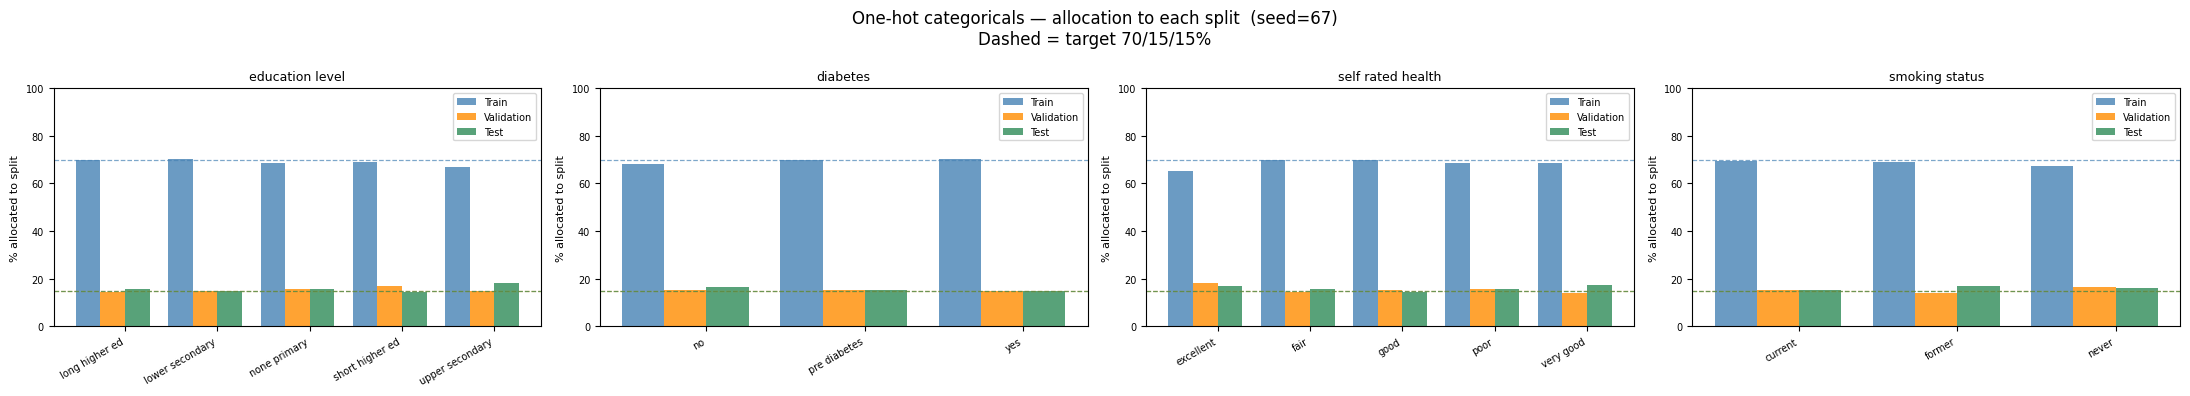

In [19]:
ref_pcts = [TRAIN_SPLIT*100, VAL_SPLIT*100, (1-TRAIN_SPLIT-VAL_SPLIT)*100]
fig, axes = plt.subplots(1, len(CATEGORICAL), figsize=(22, 4))

for ax, cat in zip(axes, CATEGORICAL):
    ohe_cols = ohe_groups[cat]
    labels   = [c.replace(cat + '_','').replace('_',' ') for c in ohe_cols]
    n_total  = norm_s[ohe_cols[0]].count()  # same for all splits

    x     = np.arange(len(labels))
    width = 0.8 / len(SPLIT_NAMES)
    colors = plt.cm.Set2.colors

    for k, (split_name, scolor) in enumerate(zip(SPLIT_NAMES, SPLIT_COLORS)):
        sub = norm_s[norm_s['split']==split_name]
        n_split = len(sub)
        # Of all subjects with this OHE=1, what fraction is in this split?
        pcts = []
        for col in ohe_cols:
            n_col_total = (norm_s[col] == 1).sum()
            n_col_split = (sub[col] == 1).sum()
            pcts.append(n_col_split / n_col_total * 100 if n_col_total else 0)
        ax.bar(x + k*width - width*len(SPLIT_NAMES)/2, pcts, width,
               label=split_name, color=scolor, alpha=0.8)

    for pct, color in zip(ref_pcts, SPLIT_COLORS):
        ax.axhline(pct, color=color, linestyle='--', lw=0.9, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
    ax.set_title(cat.replace('_',' '), fontsize=9)
    ax.set_ylabel('% allocated to split', fontsize=8)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)

plt.suptitle(f'One-hot categoricals — allocation to each split  (seed={SEED})\n'
             f'Dashed = target {TRAIN_SPLIT*100:.0f}/{VAL_SPLIT*100:.0f}/'
             f'{(1-TRAIN_SPLIT-VAL_SPLIT)*100:.0f}%',
             fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
print("One-hot column means per split  (mean = fraction with that category)\n")
for cat in CATEGORICAL:
    ohe_cols  = ohe_groups[cat]
    short_lbl = [c.replace(cat + '_','') for c in ohe_cols]
    tbl = norm_s.groupby('split', observed=True)[ohe_cols].mean().round(4) * 100
    tbl.columns = short_lbl
    tbl['Total subjects'] = norm_s.groupby('split', observed=True).size()
    print(f"── {cat} (values = % of split)  ──")
    display(tbl)
    print()

One-hot column means per split  (mean = fraction with that category)

── education_level (values = % of split)  ──


,long_higher_ed,lower_secondary,none_primary,short_higher_ed,upper_secondary,Total subjects
split,,,,,,
Train,16.84,16.84,5.41,22.04,38.88,481
Validation,15.74,15.74,5.56,24.07,38.89,108
Test,15.79,14.91,5.26,19.30,44.74,114



── diabetes (values = % of split)  ──


,no,pre_diabetes,yes,Total subjects
split,,,,
Train,85.45,7.69,6.86,481
Validation,86.11,7.41,6.48,108
Test,86.84,7.02,6.14,114



── self_rated_health (values = % of split)  ──


,excellent,fair,good,poor,very_good,Total subjects
split,,,,,,
Train,19.33,9.15,30.98,5.41,35.14,481
Validation,24.07,8.33,30.56,5.56,31.48,108
Test,21.05,8.77,27.19,5.26,37.72,114



── smoking_status (values = % of split)  ──


,current,former,never,Total subjects
split,,,,
Train,19.96,36.59,43.45,481
Validation,19.44,33.33,47.22,108
Test,18.42,37.72,43.86,114
